## Análisis Exploratorio de Datos (EDA)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("veterinary_clinical_dataset_clean.csv")
df.head()

,AnimalName,Breed,Age,Weight_kg,MedicalHistory,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5
0,dog,rottweiler,6.0,32.1,chronic illness,anorexia,hydrophobia,drooping ears,diarrhea,shyness or aggression
1,dog,bulldog,9.9,18.5,vaccinated,lethargy,weakness,horny growth,fever,coughing
2,dog,beagle,13.9,18.9,parasite history,pain,weight loss,weight loss,sneezing,drop on egg production
3,cat,scottish fold,5.8,6.3,recent surgery,vomiting,pain,edema in lower jaw,pain,weakness
4,cat,persian,11.2,4.9,recent surgery,severe,weight loss,egg production stops,weakness,poor body condition


### istribución de variables categóricas principales

C:\Users\Usuario\AppData\Local\Temp\ipykernel_34356\3376304973.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="AnimalName", data=df, ax=axes[0], palette="Set2")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_34356\3376304973.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_breeds.values, y=top_breeds.index, palette="viridis", ax=axes[1])


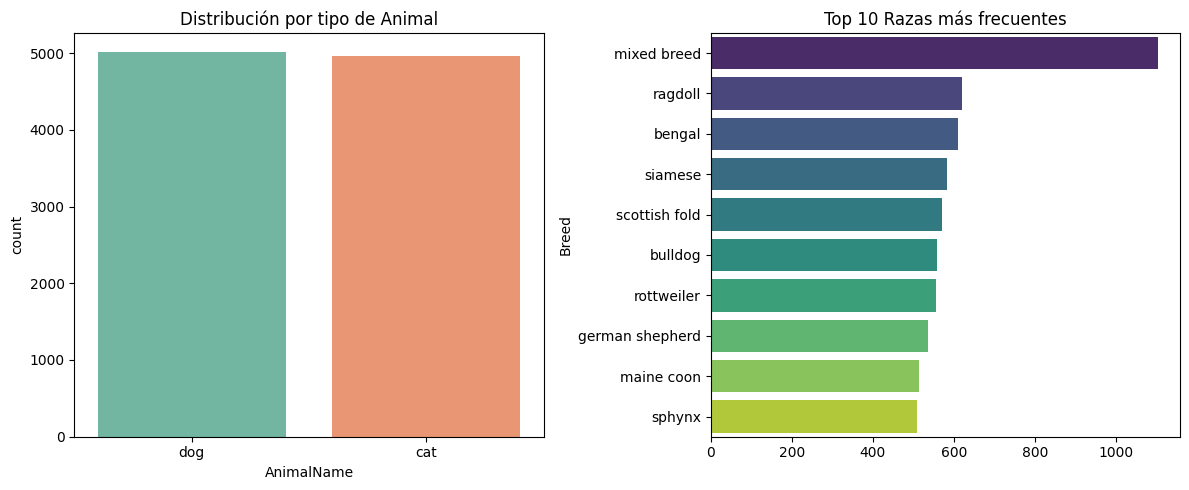

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x="AnimalName", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Distribución por tipo de Animal")

top_breeds = df['Breed'].value_counts().head(10)
sns.barplot(x=top_breeds.values, y=top_breeds.index, palette="viridis", ax=axes[1])
axes[1].set_title("Top 10 Razas más frecuentes")
plt.tight_layout()
plt.show()

### Distribución de variables numéricas (Edad y Peso)

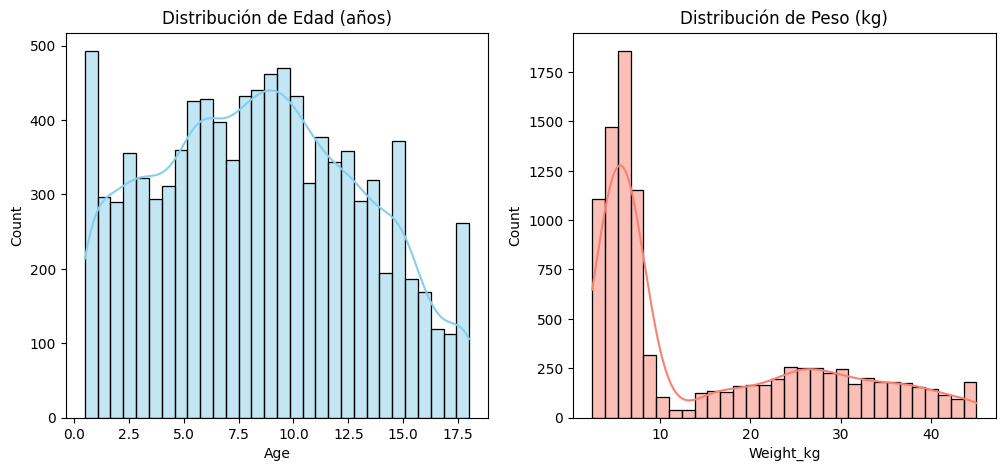

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribución de Edad (años)")

sns.histplot(df['Weight_kg'], bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Distribución de Peso (kg)")
plt.show()

### Frecuencia de síntomas reportados

C:\Users\Usuario\AppData\Local\Temp\ipykernel_34356\2308641043.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=symptom_counts.values, y=symptom_counts.index, palette="magma")


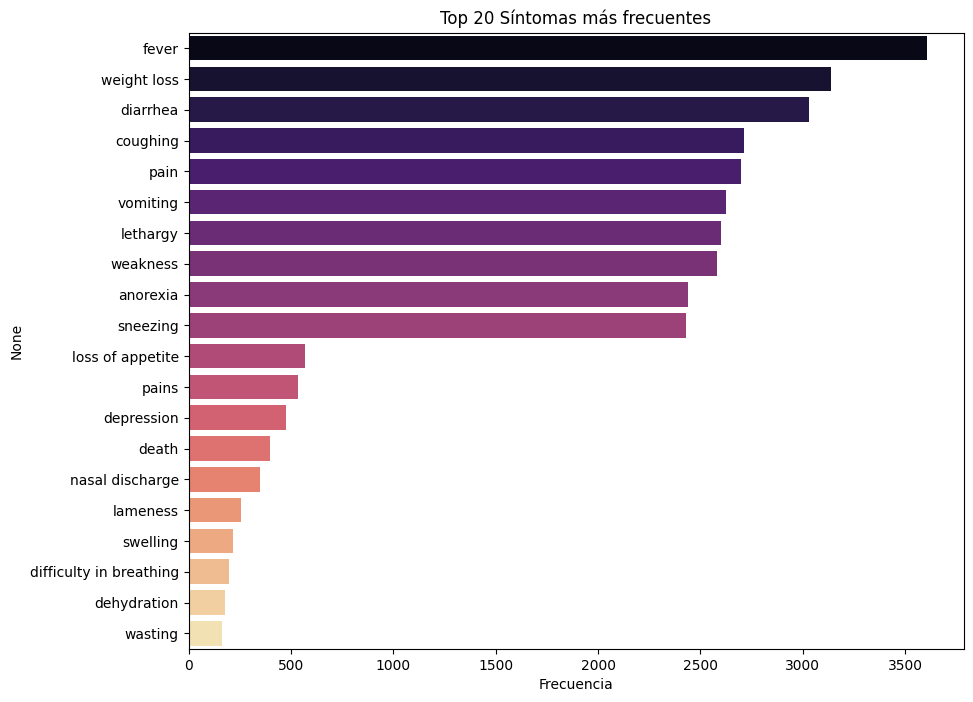

In [5]:
symptom_cols = [col for col in df.columns if "Symptom" in col]
symptoms_series = pd.concat([df[col] for col in symptom_cols]).str.lower().str.strip()
symptom_counts = symptoms_series.value_counts().head(20)

plt.figure(figsize=(10,8))
sns.barplot(x=symptom_counts.values, y=symptom_counts.index, palette="magma")
plt.title("Top 20 Síntomas más frecuentes")
plt.xlabel("Frecuencia")
plt.show()

### Correlación entre variables clínicas (Edad y Peso)

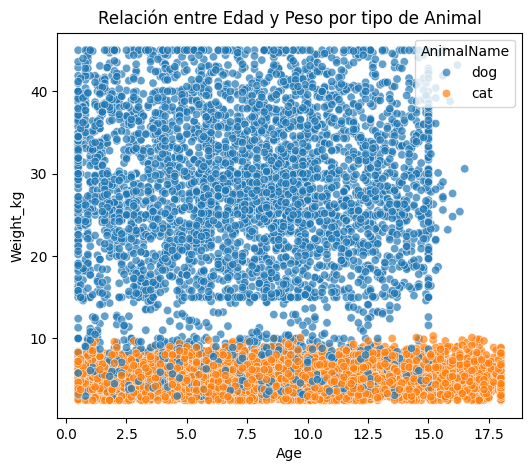

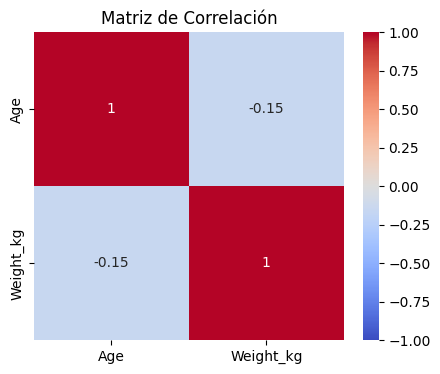

In [6]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="Age", y="Weight_kg", hue="AnimalName", data=df, alpha=0.7)
plt.title("Relación entre Edad y Peso por tipo de Animal")
plt.show()

# Heatmap de correlación numérica
plt.figure(figsize=(5,4))
sns.heatmap(df[["Age", "Weight_kg"]].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlación")
plt.show()

### Correlación entre variables categóricas (AnimalName, Breed, MedicalHistory)


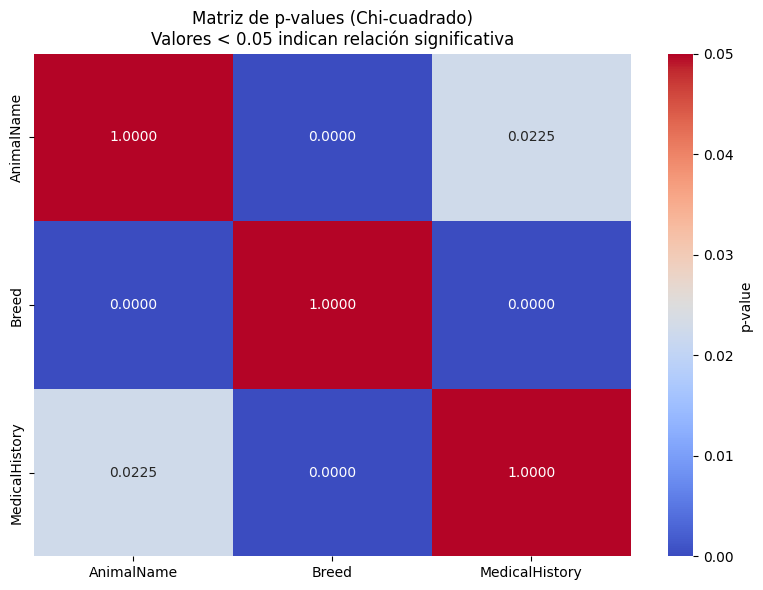

In [7]:
from scipy.stats import chi2_contingency
categorical_vars = ['AnimalName', 'Breed', 'MedicalHistory']

# Crear matriz de p-values para Chi-cuadrado
chi2_results = pd.DataFrame(index=categorical_vars, columns=categorical_vars)

for var1 in categorical_vars:
    for var2 in categorical_vars:
        if var1 == var2:
            chi2_results.loc[var1, var2] = 1.0
        else:
            contingency_table = pd.crosstab(df[var1], df[var2])
            chi2, p_value, dof, expected = chi2_contingency(contingency_table)
            chi2_results.loc[var1, var2] = p_value

# Convertir a float para visualización
chi2_results = chi2_results.astype(float)

plt.figure(figsize=(8,6))
sns.heatmap(chi2_results, annot=True, fmt='.4f', cmap='coolwarm', 
            vmin=0, vmax=0.05, cbar_kws={'label': 'p-value'})
plt.title('Matriz de p-values (Chi-cuadrado)\nValores < 0.05 indican relación significativa')
plt.tight_layout()
plt.show()

## Análisis Exploratorio de Datos de Imágenes

En esta sección realizamos EDA sobre los datasets de imágenes de perros. El objetivo es explorar la distribución de clases, tamaños de imágenes y su calidad.

In [8]:
import os, random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base_dog = "dog_skin_disease_split"

def get_image_info(base_dir):
    info = []
    for split in ["train", "valid", "test"]:
        split_path = os.path.join(base_dir, split)
        for cls in os.listdir(split_path):
            cls_path = os.path.join(split_path, cls)
            for file in os.listdir(cls_path):
                if file.lower().endswith((".jpg",".jpeg",".png")):
                    path = os.path.join(cls_path, file)
                    try:
                        img = Image.open(path)
                        w, h = img.size
                        info.append({
                            'split': split,
                            'class': cls,
                            'width': w,
                            'height': h,
                            'aspect_ratio': w/h,
                            'mode': img.mode,
                            'size_kb': os.path.getsize(path)/1024
                        })
                    except:
                        pass
    return pd.DataFrame(info)

df_dog = get_image_info(base_dog)

print("Perros:", df_dog.shape)
df_dog.head(10)

Perros: (4176, 7)


,split,class,width,height,aspect_ratio,mode,size_kb
0,train,demodicosis,640,640,1.0,RGB,79.783203
1,train,demodicosis,640,640,1.0,RGB,71.637695
2,train,demodicosis,640,640,1.0,RGB,54.958008
3,train,demodicosis,640,640,1.0,RGB,47.996094
4,train,demodicosis,640,640,1.0,RGB,55.733398
5,train,demodicosis,640,640,1.0,RGB,63.513672
6,train,demodicosis,640,640,1.0,RGB,49.028320
7,train,demodicosis,640,640,1.0,RGB,50.833008
8,train,demodicosis,640,640,1.0,RGB,46.407227
9,train,demodicosis,640,640,1.0,RGB,50.494141


### Distribución de imágenes por clase y split

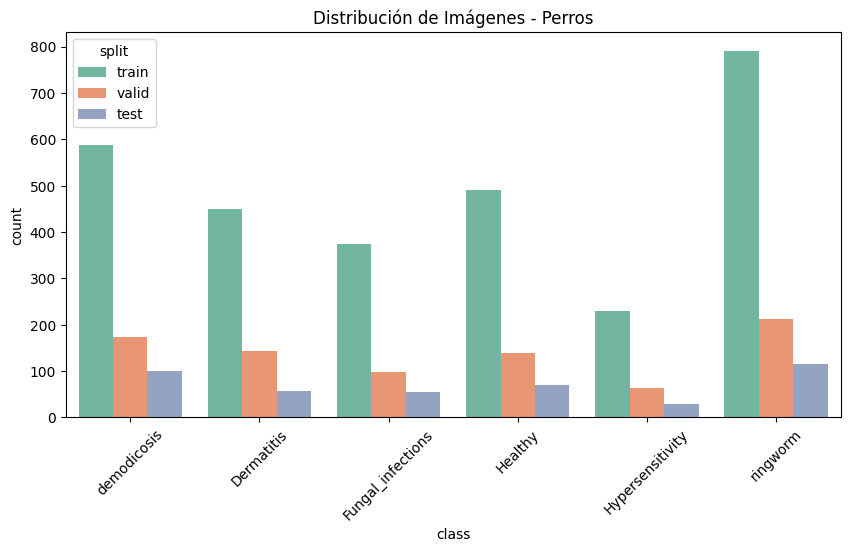

In [10]:
def plot_distribution(df, title):
    plt.figure(figsize=(10,5))
    sns.countplot(x="class", hue="split", data=df, palette="Set2")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

plot_distribution(df_dog, "Distribución de Imágenes - Perros")

### Ejemplos de imágenes por clase

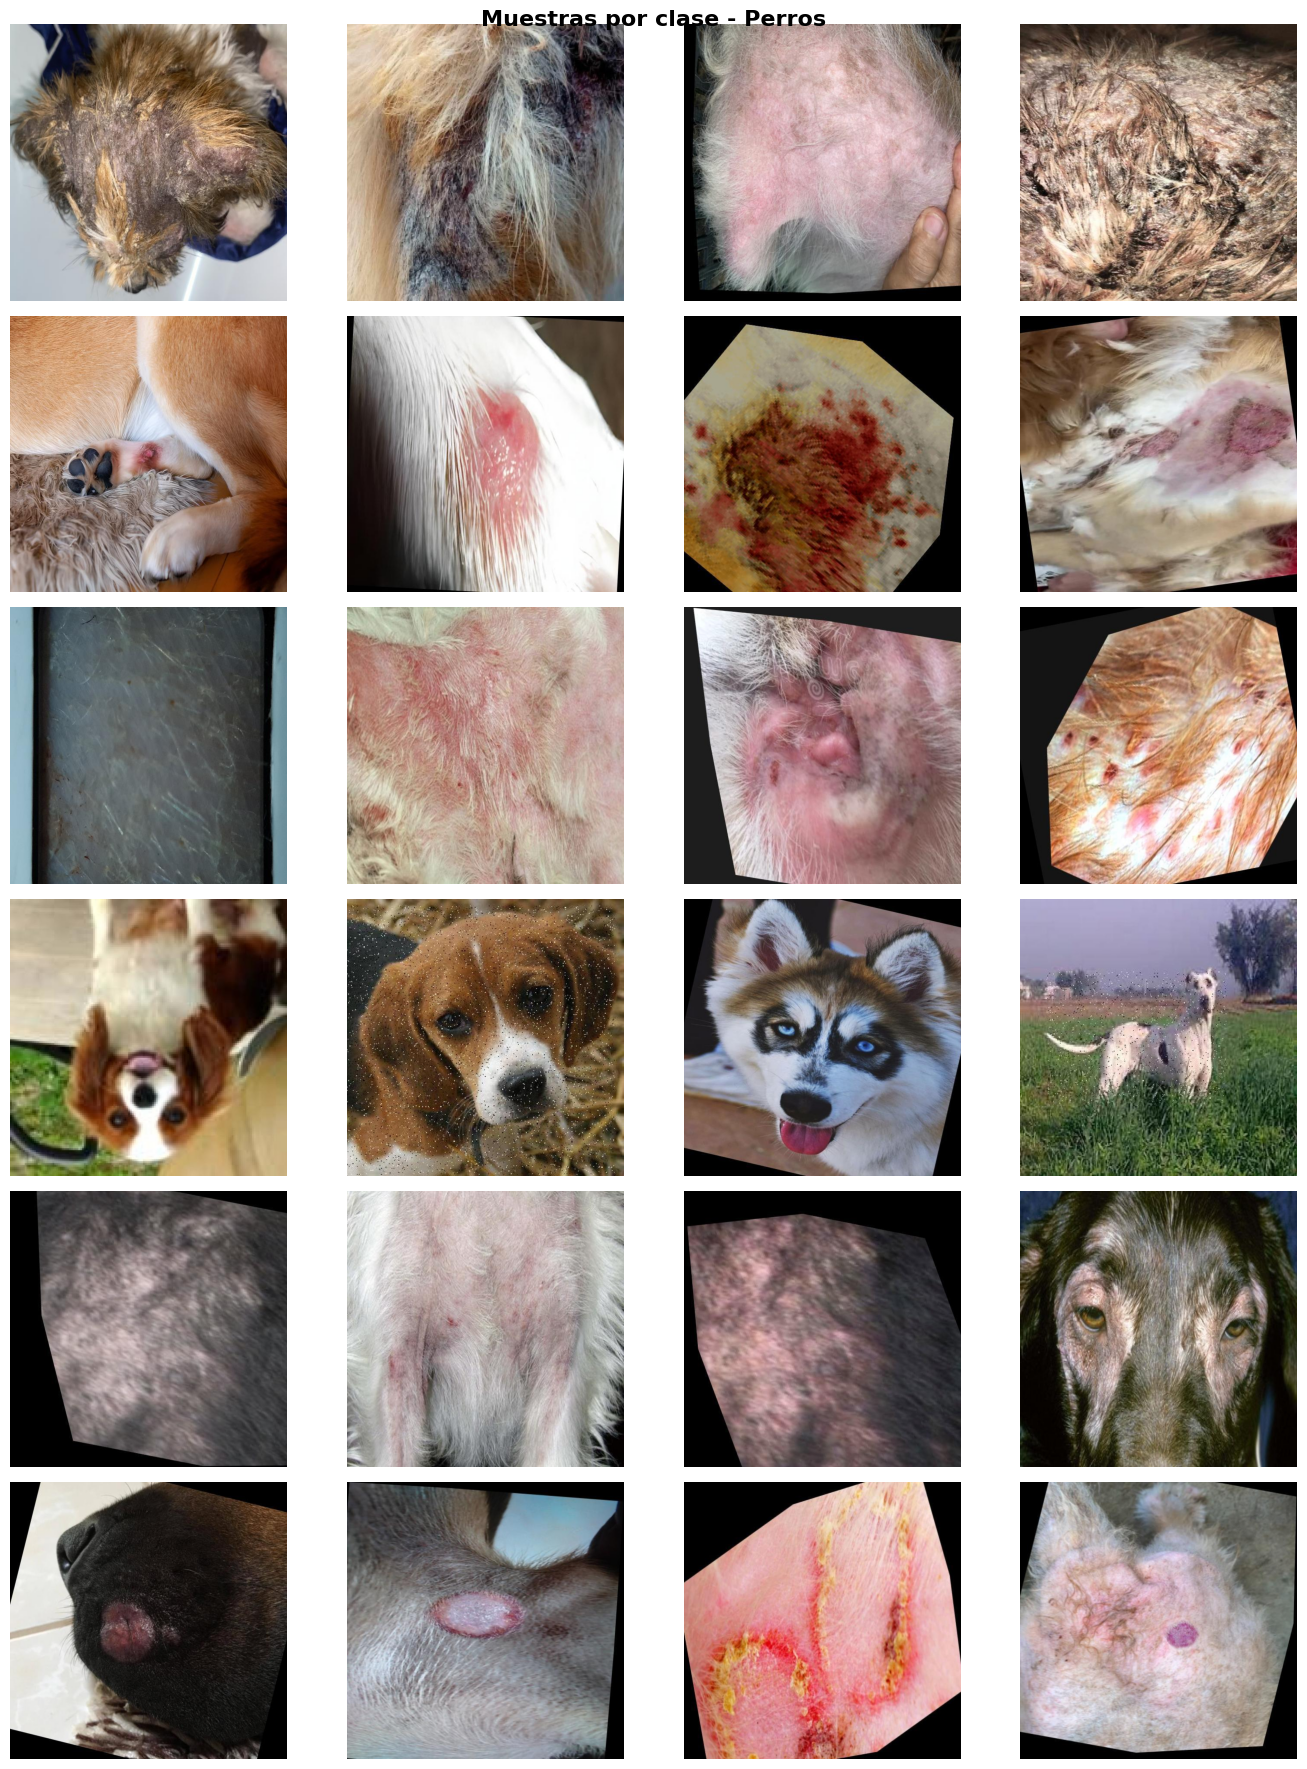

In [11]:
def show_samples(base_dir, classes, title):
    fig, axes = plt.subplots(len(classes), 4, figsize=(14, 3*len(classes)))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    for i, cls in enumerate(classes):
        path = os.path.join(base_dir, 'train', cls)
        files = [f for f in os.listdir(path) if f.lower().endswith((".jpg",".jpeg",".png"))]
        for j in range(4):
            file = random.choice(files)
            img = Image.open(os.path.join(path, file))
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j==0:
                axes[i, j].set_ylabel(cls, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(base_dog, df_dog['class'].unique(), "Muestras por clase - Perros")

### Distribución de dimensiones y aspect ratio

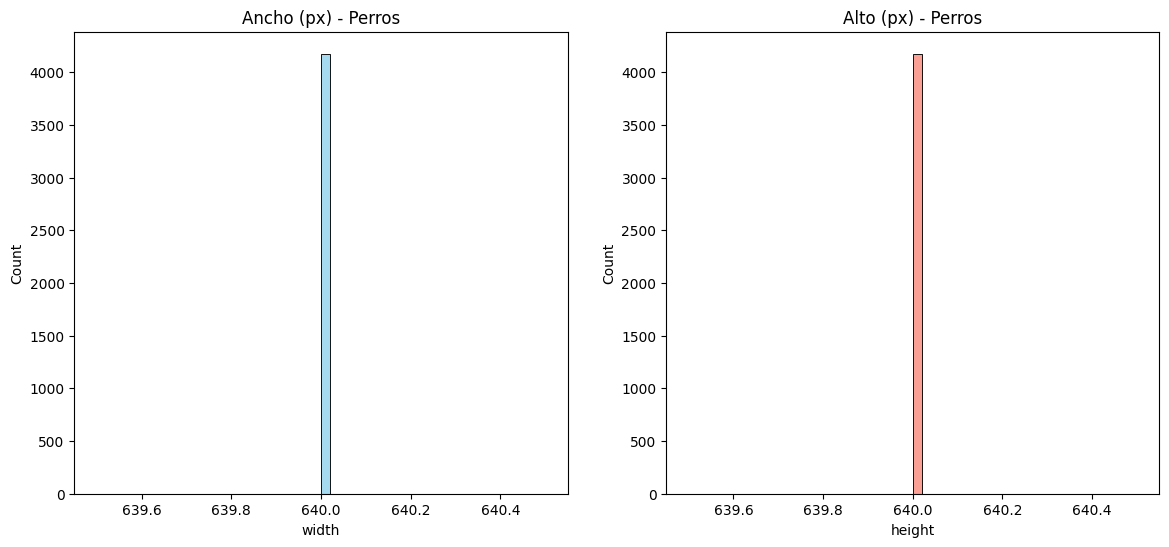

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df_dog['width'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title("Ancho (px) - Perros")
sns.histplot(df_dog['height'], bins=50, ax=axes[1], color='salmon')
axes[1].set_title("Alto (px) - Perros")
plt.show()

### Distribución de tamaño de archivos

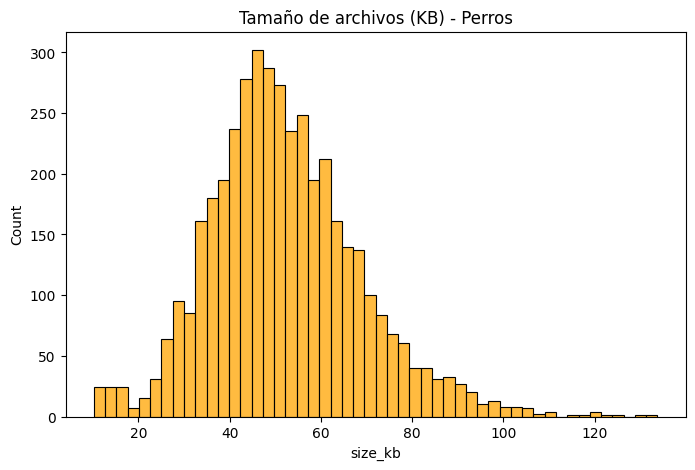

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(df_dog['size_kb'], bins=50, ax=ax, color='orange')
ax.set_title("Tamaño de archivos (KB) - Perros")
plt.show()

### Modos de color

C:\Users\Usuario\AppData\Local\Temp\ipykernel_34356\405920901.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='mode', data=df_dog, ax=ax, palette='Set3')


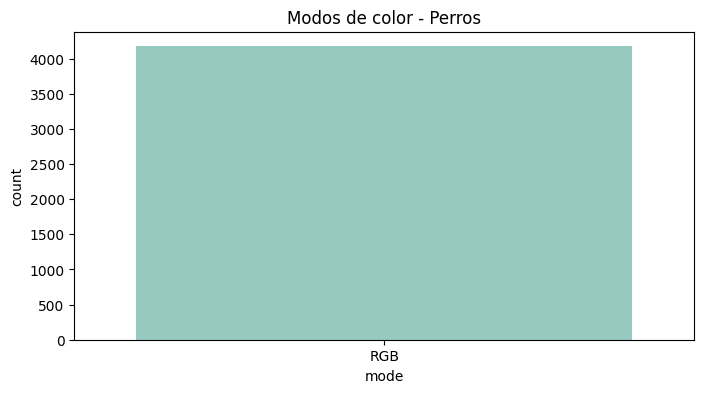

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.countplot(x='mode', data=df_dog, ax=ax, palette='Set3')
ax.set_title("Modos de color - Perros")
plt.show()